# Stock Price Forecasting with an LSTM (PyTorch)

Forecasting Microsoft's (MSFT) next-day closing price with a two-layer LSTM built in PyTorch.

Instead of predicting the raw price, the model predicts **tomorrow's percent return** from the previous
50 trading days of engineered features (daily returns, moving-average gaps, RSI, volume and the Nasdaq-100 market return).
The predicted return is then converted back into a price.

| | |
|---|---|
| **Data** | Daily MSFT and QQQ (Nasdaq-100 ETF) prices from Yahoo Finance, 2010 to present |
| **Train / validation / test** | 2010–2024 / 2025 / 2026 (split by date, so the model never sees the future) |
| **Metrics** | MAE, MAPE, MDAPE and direction accuracy, each compared with a simple baseline |

*Based on a project from the Harvard AI Bootcamp, extended with return-based targets, technical indicators,
market data, leakage-free scaling and early stopping.*

## 1. Load the Data

In [14]:
import copy
import numpy as np
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import yfinance as yf

sns.set_style('white', {'axes.spines.right': False, 'axes.spines.top': False})
torch.manual_seed(42)  # makes results repeatable between runs
np.random.seed(42)

In [15]:
# Timeframe for the data download
start_date = '2010-01-01'
end_date = date.today().strftime("%Y-%m-%d")

stockname = 'Microsoft (MSFT)'
symbol = 'MSFT'
market_symbol = 'QQQ'  # Nasdaq-100 ETF, used as a market-wide signal

def download(ticker):
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    # Newer yfinance versions return two header levels (Price, Ticker); keep only the first
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    return data

df = download(symbol)
market = download(market_symbol)
print(df.shape, market.shape)

(4206, 5) (4206, 5)


## 2. Explore the Data

In [16]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,22.984238,23.095631,22.716892,22.739172,38409100
2010-01-05,22.991663,23.095631,22.754023,22.909975,49749600
2010-01-06,22.850567,23.080780,22.664911,22.932255,58182400
2010-01-07,22.612932,22.798588,22.419850,22.746604,50559700
2010-01-08,22.768877,22.932254,22.456975,22.486680,51197400


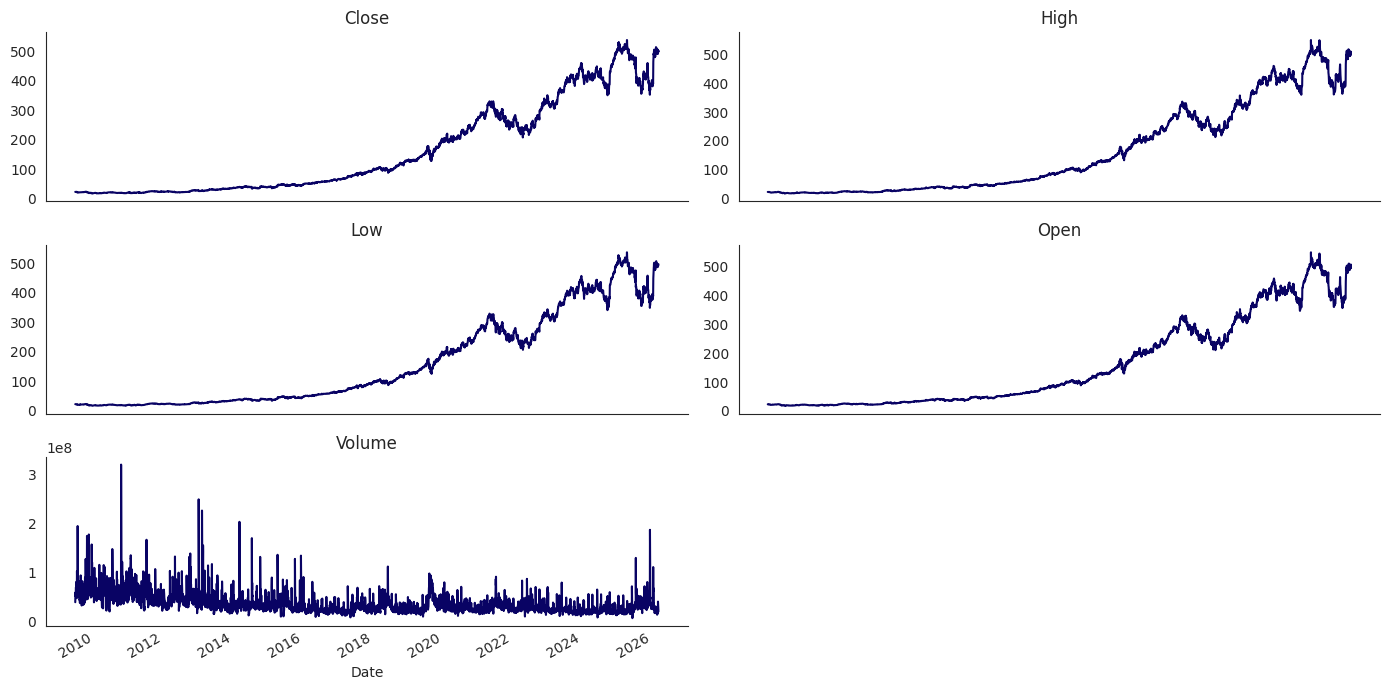

In [17]:
# Plot each column over time
ncols = 2
nrows = int(np.ceil(df.shape[1] / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i >= df.shape[1]:
        ax.set_visible(False)
        continue
    sns.lineplot(data=df.iloc[:, i], ax=ax)
    ax.set_title(df.columns[i])
    ax.set_ylabel('')
    ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.tight_layout()
plt.show()

## 3. Feature Engineering and Data Split

Raw prices keep climbing to levels the model never saw in training, and neural networks extrapolate poorly.
Percent changes and ratios stay in a similar range across the whole history, so every feature below is
scale-free.

The data is split by date: **2010–2024 for training, 2025 for validation (early stopping) and 2026 for testing.**

In [18]:
def rsi(close, window=14):
    """Relative Strength Index (Wilder's smoothing), scaled 0-100."""
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / window, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / window, adjust=False).mean()
    return 100 - 100 / (1 + gain / loss)

In [19]:
feat = pd.DataFrame(index=df.index)
feat['return'] = df['Close'].pct_change()                        # today's % return
feat['high_low_range'] = (df['High'] - df['Low']) / df['Close']  # intraday volatility
feat['open_close'] = (df['Close'] - df['Open']) / df['Open']     # intraday direction
feat['volume_ratio'] = np.log(df['Volume'] / df['Volume'].rolling(20).mean())  # volume vs. 20-day average
feat['ma10_gap'] = df['Close'] / df['Close'].rolling(10).mean() - 1   # distance from 10-day moving average
feat['ma50_gap'] = df['Close'] / df['Close'].rolling(50).mean() - 1   # distance from 50-day moving average
feat['rsi14'] = rsi(df['Close']) / 100                           # momentum indicator
feat['market_return'] = market['Close'].pct_change().reindex(df.index)  # Nasdaq-100 daily return

FEATURES = list(feat.columns)

# Target: tomorrow's % return
feat['target'] = df['Close'].shift(-1) / df['Close'] - 1
feat['close'] = df['Close']

# Drop warm-up rows where rolling features aren't defined yet.
# The very last row has no target (tomorrow is unknown); it's kept for the live prediction in step 6.
feat = feat.dropna(subset=FEATURES)
print('Features:', FEATURES)
feat.tail()

Features: ['return', 'high_low_range', 'open_close', 'volume_ratio', 'ma10_gap', 'ma50_gap', 'rsi14', 'market_return']


,return,high_low_range,open_close,volume_ratio,ma10_gap,ma50_gap,rsi14,market_return,target,close
Date,,,,,,,,,,
2026-09-17,0.015195,0.016675,-0.000100,-0.117882,0.000690,0.077389,0.557149,0.017312,-0.007976,497.750000
2026-09-18,-0.007976,0.015290,-0.008414,0.632308,-0.004020,0.063724,0.532595,0.006319,0.015857,493.779999
2026-09-21,0.015857,0.021012,0.013456,0.270830,0.011384,0.075161,0.572602,0.028821,-0.007197,501.609985
2026-09-22,-0.007197,0.029819,-0.018371,0.004879,0.003286,0.062515,0.549259,0.008079,0.005201,498.000000
2026-09-23,0.005201,0.027088,-0.000340,-0.102464,0.006691,0.062763,0.563023,-0.008362,NaN,500.589996


In [20]:
# Train / validation / test split and scaling.
# Each sample is a 50-day window of features, labeled with the date of the day being predicted.
# The scalers are fitted on training rows only, so no information from 2025 or 2026 leaks into preprocessing.
sequence_length = 50
val_start, test_start = '2025-01-01', '2026-01-01'

# Fit the scalers on training-period rows only
train_rows = feat.index < val_start
feature_scaler = StandardScaler().fit(feat.loc[train_rows, FEATURES].values)
target_scaler = StandardScaler().fit(feat.loc[train_rows & feat['target'].notna(), ['target']].values)

X_all = feature_scaler.transform(feat[FEATURES].values)

# Build sliding windows: the previous sequence_length days -> the next day's return
x, y, target_dates, prev_close, next_close = [], [], [], [], []
closes = feat['close'].values
targets = feat['target'].values
for i in range(sequence_length - 1, len(feat) - 1):  # the last row has no target
    x.append(X_all[i - sequence_length + 1:i + 1])
    y.append(targets[i])
    target_dates.append(feat.index[i + 1])
    prev_close.append(closes[i])
    next_close.append(closes[i + 1])

x = np.array(x, dtype=np.float32)
y = target_scaler.transform(np.array(y).reshape(-1, 1)).astype(np.float32).ravel()
target_dates = pd.DatetimeIndex(target_dates)
prev_close, next_close = np.array(prev_close), np.array(next_close)

# Split by the date being predicted
train_idx = target_dates < val_start
val_idx = (target_dates >= val_start) & (target_dates < test_start)
test_idx = target_dates >= test_start

x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]
x_test, y_test = x[test_idx], y[test_idx]

print('Train:', x_train.shape, '| Validation:', x_val.shape, '| Test:', x_test.shape)

Train: (3675, 50, 8) | Validation: (250, 50, 8) | Test: (182, 50, 8)


## 4. Model Training

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.relu(self.fc1(out[:, -1, :]))  # use the output from the last time step
        return self.fc2(out)

class TimeSeriesDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.from_numpy(x)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [22]:
# Hyperparameters
input_size = len(FEATURES)
hidden_size = 64
num_layers = 2
output_size = 1
learning_rate = 1e-3
batch_size = 32
epochs = 40
patience = 8  # stop if validation loss hasn't improved for this many epochs

model = LSTMModel(input_size, hidden_size, num_layers, output_size)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_dataloader = DataLoader(TimeSeriesDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
x_val_t, y_val_t = torch.from_numpy(x_val), torch.from_numpy(y_val)

history = {'train': [], 'val': []}
best_val, best_state, epochs_without_improvement = float('inf'), None, 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for x_batch, y_batch in train_dataloader:
        outputs = model(x_batch)                         # forward pass
        loss = criterion(outputs, y_batch.unsqueeze(1))
        optimizer.zero_grad()                            # clear old gradients
        loss.backward()                                  # backpropagation
        optimizer.step()                                 # update weights
        epoch_loss += loss.item()

    # Check performance on the 2025 validation set
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(x_val_t), y_val_t.unsqueeze(1)).item()

    history['train'].append(epoch_loss / len(train_dataloader))
    history['val'].append(val_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {history['train'][-1]:.4f}, Val Loss: {val_loss:.4f}")

    # Early stopping: keep the weights from the best validation epoch
    if val_loss < best_val:
        best_val, best_state, epochs_without_improvement = val_loss, copy.deepcopy(model.state_dict()), 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f'Early stopping: no improvement for {patience} epochs')
            break

model.load_state_dict(best_state)
print(f'Best validation loss: {best_val:.4f}')

Epoch [1/40], Train Loss: 0.7000, Val Loss: 0.6242
Epoch [2/40], Train Loss: 0.6970, Val Loss: 0.6232
Epoch [3/40], Train Loss: 0.6966, Val Loss: 0.6225
Epoch [4/40], Train Loss: 0.6963, Val Loss: 0.6230
Epoch [5/40], Train Loss: 0.6954, Val Loss: 0.6225
Epoch [6/40], Train Loss: 0.6954, Val Loss: 0.6266
Epoch [7/40], Train Loss: 0.6950, Val Loss: 0.6264
Epoch [8/40], Train Loss: 0.6935, Val Loss: 0.6326
Epoch [9/40], Train Loss: 0.6972, Val Loss: 0.6218
Epoch [10/40], Train Loss: 0.6950, Val Loss: 0.6223
Epoch [11/40], Train Loss: 0.6934, Val Loss: 0.6231
Epoch [12/40], Train Loss: 0.6914, Val Loss: 0.6226
Epoch [13/40], Train Loss: 0.6911, Val Loss: 0.6232
Epoch [14/40], Train Loss: 0.6893, Val Loss: 0.6264
Epoch [15/40], Train Loss: 0.6873, Val Loss: 0.6241
Epoch [16/40], Train Loss: 0.6862, Val Loss: 0.6309
Epoch [17/40], Train Loss: 0.6865, Val Loss: 0.6261
Early stopping: no improvement for 8 epochs
Best validation loss: 0.6218


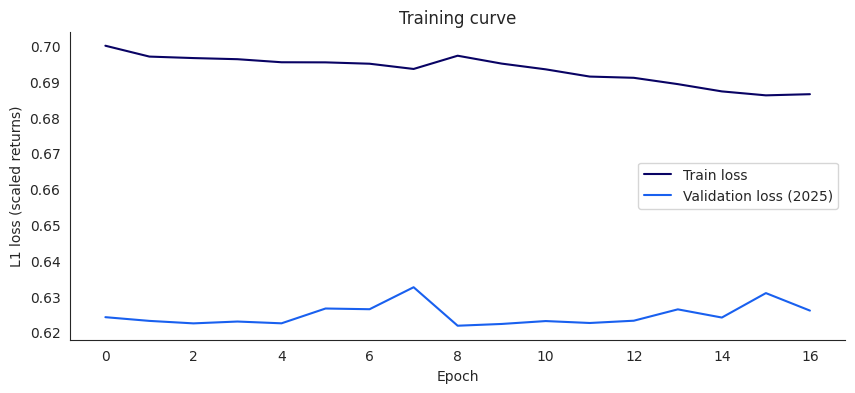

In [23]:
# Training curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train'], label='Train loss')
ax.plot(history['val'], label='Validation loss (2025)')
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 loss (scaled returns)')
ax.set_title('Training curve')
ax.legend()
plt.show()

## 5. Evaluate on 2026

In [24]:
model.eval()
with torch.no_grad():
    pred_scaled = model(torch.from_numpy(x_test)).numpy()

# Convert predicted returns back to prices: tomorrow = today * (1 + predicted return)
pred_return = target_scaler.inverse_transform(pred_scaled).ravel()
actual_return = target_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
today_price = prev_close[test_idx]
y_test_price = next_close[test_idx]
y_pred_price = today_price * (1 + pred_return)

def mape(actual, pred):
    return np.mean(np.abs(actual - pred) / actual) * 100

print(f'Results on 2026 test data ({len(y_test_price)} trading days):')
print(f'Mean Absolute Error (MAE): ${mean_absolute_error(y_test_price, y_pred_price):.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape(y_test_price, y_pred_price):.2f} %')
print(f'Median Absolute Percentage Error (MDAPE): {np.median(np.abs(y_test_price - y_pred_price) / y_test_price) * 100:.2f} %')

# Baseline 1: tomorrow's price = today's price
print(f'Baseline MAPE (tomorrow = today): {mape(y_test_price, today_price):.2f} %')

# Direction accuracy: did the model get up vs. down right?
direction_acc = np.mean(np.sign(pred_return) == np.sign(actual_return)) * 100
up_days = np.mean(actual_return > 0) * 100
print(f'Direction accuracy: {direction_acc:.1f} %')
print(f'Baseline direction accuracy (always guess "up"): {up_days:.1f} %')

Results on 2026 test data (182 trading days):
Mean Absolute Error (MAE): $6.68
Mean Absolute Percentage Error (MAPE): 1.58 %
Median Absolute Percentage Error (MDAPE): 1.27 %
Baseline MAPE (tomorrow = today): 1.57 %
Direction accuracy: 49.5 %
Baseline direction accuracy (always guess "up"): 48.9 %


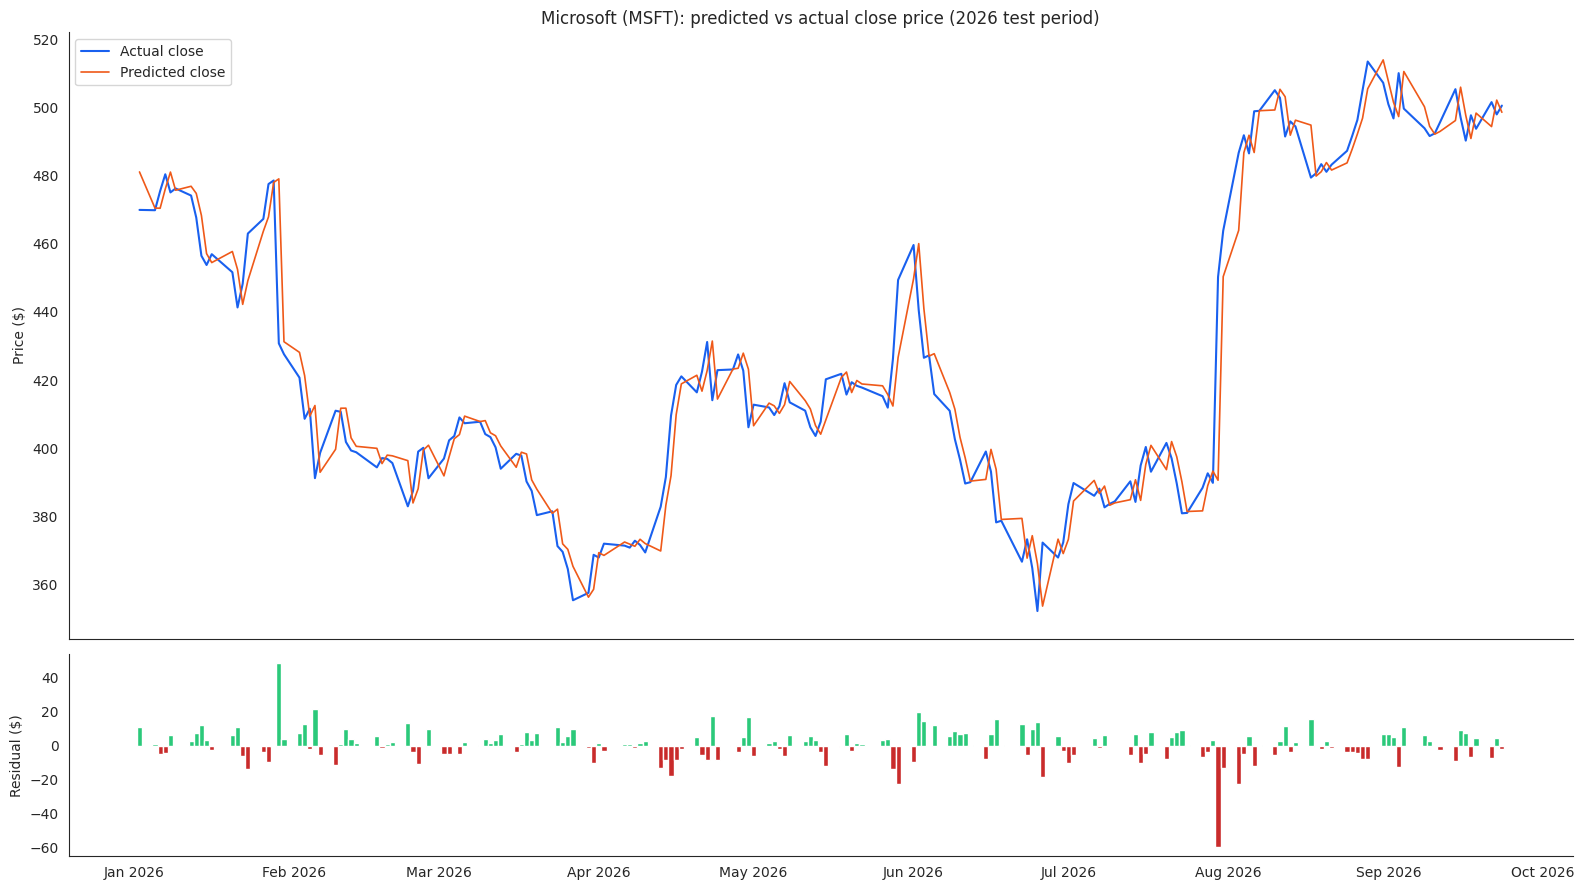

In [25]:
# Predicted vs actual prices for 2026, with residuals (prediction - actual)
results = pd.DataFrame({'Actual': y_test_price, 'Predicted': y_pred_price},
                       index=target_dates[test_idx])
residuals = results['Predicted'] - results['Actual']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(results.index, results['Actual'], label='Actual close', color='#1960EF', linewidth=1.5)
ax1.plot(results.index, results['Predicted'], label='Predicted close', color='#EF5919', linewidth=1.2)
ax1.set_title(f'{stockname}: predicted vs actual close price (2026 test period)')
ax1.set_ylabel('Price ($)')
ax1.legend()

colors = ['#2BC97A' if r > 0 else '#C92B2B' for r in residuals]  # green = overestimate, red = underestimate
ax2.bar(residuals.index, residuals, color=colors, width=1)
ax2.set_ylabel('Residual ($)')
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.tight_layout()
plt.show()

## 6. Predict the Next Trading Day

In [26]:
# The most recent 50 days of features (the last row has no target yet, which is exactly the day we want to predict from)
last_window = X_all[-sequence_length:].astype(np.float32)[np.newaxis, :, :]  # shape (1, 50, features)

model.eval()
with torch.no_grad():
    next_return = target_scaler.inverse_transform(model(torch.from_numpy(last_window)).numpy()).item()

price_today = float(feat['close'].iloc[-1])
predicted_price = price_today * (1 + next_return)

print(f'Last close for {stockname} ({feat.index[-1].date()}): ${price_today:.2f}')
print(f'Predicted next close: ${predicted_price:.2f} ({next_return * 100:+.2f}%)')

Last close for Microsoft (MSFT) (2026-09-23): $500.59
Predicted next close: $501.21 (+0.12%)


## Results and Takeaways

Results on the 2026 test set (182 trading days, from a run on September 24, 2026):

| Model | MAPE | Direction accuracy |
|---|---|---|
| Version 1: LSTM on raw prices | 2.43% | – |
| **Version 2: LSTM on returns + engineered features (this notebook)** | **1.58%** | **49.5%** |
| Baseline: tomorrow's price = today's price | 1.57% | – |
| Baseline: always guess "up" | – | 48.9% |

- **Predicting returns instead of prices cut the error by about a third** compared with version 1, and removed the
  systematic lag where the model underpredicted prices above its training range.
- **The model only ties the naive baseline, and its direction accuracy is essentially a coin flip.** Validation loss
  stopped improving after about 9 epochs and early stopping ended training at epoch 17: the network found no pattern in
  past prices and indicators that carried over to unseen data.
- This matches the *efficient-market* view that daily returns are close to unpredictable from public price history.
  Without baselines and a strict date-based split, an LSTM price chart can look impressive while adding nothing over
  "tomorrow = today". Measuring that honestly is the main result of this project.

**Ideas for further work**
- Walk-forward evaluation (retrain as each new month of data arrives)
- Predicting volatility or multi-day horizons, which are more predictable than next-day direction
- Comparing with simpler models (linear regression, gradient boosting) on the same features